1. Analisis Exploratorio de Datos

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
# Leemos el dataset e imprimimos un fragmento aleatorio.
df = pd.read_csv("../data/raw/casas_dev.csv")
df.sample(10)

,precio,tipo,Área,metros_cubiertos,unidades,ambientes,pisos,pileta,lat,lon,edad
732,44838.661449,casa,257.929006,117.758370,m2,5,2.0,False,-34.702300,-58.250140,NaN
52,148477.588551,depto,678.818091,673.804432,sqft,6,NaN,False,40.730947,-73.939891,13.450662
1421,22345.133133,casa,240.881526,129.738314,m2,10,3.0,False,-34.699292,-58.218246,42.075410
567,147519.750996,depto,772.104733,737.639360,sqft,3,NaN,False,40.763747,-73.978583,NaN
1048,40822.196887,casa,251.333456,103.604623,m2,10,3.0,True,-34.812892,-58.258916,57.709179
476,43144.340431,casa,254.086841,177.187882,m2,10,3.0,False,-34.812593,-58.197005,45.604033
1380,5184.494428,depto,75.566420,74.670329,m2,5,NaN,False,-34.808129,-58.274352,1.417197
422,24052.200914,casa,211.184538,148.115156,m2,10,3.0,True,-34.716305,-58.256041,18.277806
1588,41826.103762,casa,252.807508,146.593793,m2,10,3.0,False,-34.720789,-58.277956,27.243919
284,185.041794,casa,223.851957,138.967678,m2,4,1.0,False,-34.812806,-58.294457,18.882494


In [32]:
print("DATAFRAME SUMMARY ACCORDING TO PANDAS: \n")
df.info()

DATAFRAME SUMMARY ACCORDING TO PANDAS: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   precio            1545 non-null   float64
 1   tipo              1600 non-null   object 
 2   Área              1600 non-null   float64
 3   metros_cubiertos  1600 non-null   float64
 4   unidades          1600 non-null   object 
 5   ambientes         1600 non-null   int64  
 6   pisos             748 non-null    float64
 7   pileta            1600 non-null   bool   
 8   lat               1600 non-null   float64
 9   lon               1600 non-null   float64
 10  edad              1451 non-null   float64
dtypes: bool(1), float64(7), int64(1), object(2)
memory usage: 126.7+ KB


Entendiendo MISSING DATA

In [33]:
print("MISSING DATA:")
df.isnull().sum()

MISSING DATA:


precio               55
tipo                  0
Área                  0
metros_cubiertos      0
unidades              0
ambientes             0
pisos               852
pileta                0
lat                   0
lon                   0
edad                149
dtype: int64

In [34]:
print("MISSING DATA PROPORTIONS: \n")

missing_precio = (df["precio"].isnull().sum() / df.shape[0]) * 100
print(f"precio: ~{missing_precio:.2f}%")

missing_pisos = (df["pisos"].isnull().sum() / df.shape[0]) * 100
print(f"pisos: ~{missing_pisos:.2f}%")

missing_edad = (df["edad"].isnull().sum() / df.shape[0]) * 100
print(f"edad: ~{missing_edad:.2f}%")


MISSING DATA PROPORTIONS: 

precio: ~3.44%
pisos: ~53.25%
edad: ~9.31%


Entendiendo UNIQUENESS

In [42]:
df.nunique()

precio              1489
tipo                   3
Área                1600
metros_cubiertos    1600
unidades               2
ambientes             10
pisos                  3
pileta                 2
lat                 1600
lon                 1600
edad                1433
dtype: int64

In [44]:
# Unique values for categorical features
print("Unique Values for 'tipo':")
print(df['tipo'].value_counts())

print("\nUnique Values for 'unidades':")
print(df['unidades'].value_counts())

print("\nDistribution 'pisos' (ignoring nulls):")
print(df['pisos'].value_counts().sort_index())

Unique Values for 'tipo':
tipo
depto    852
casa     662
ph        86
Name: count, dtype: int64

Unique Values for 'unidades':
unidades
m2      907
sqft    693
Name: count, dtype: int64

Distribution 'pisos' (ignoring nulls):
pisos
1.0     80
2.0    126
3.0    542
Name: count, dtype: int64


In [41]:
print(df['pisos'].isna().groupby(df['tipo']).sum()) # los deptos no tienen pisos
# no es que falta el value, sino que ES NO APLICABLE para departamentos el feature pisos!!!


tipo
casa       0
depto    852
ph         0
Name: pisos, dtype: int64


Entendiendo TARGET PRICE

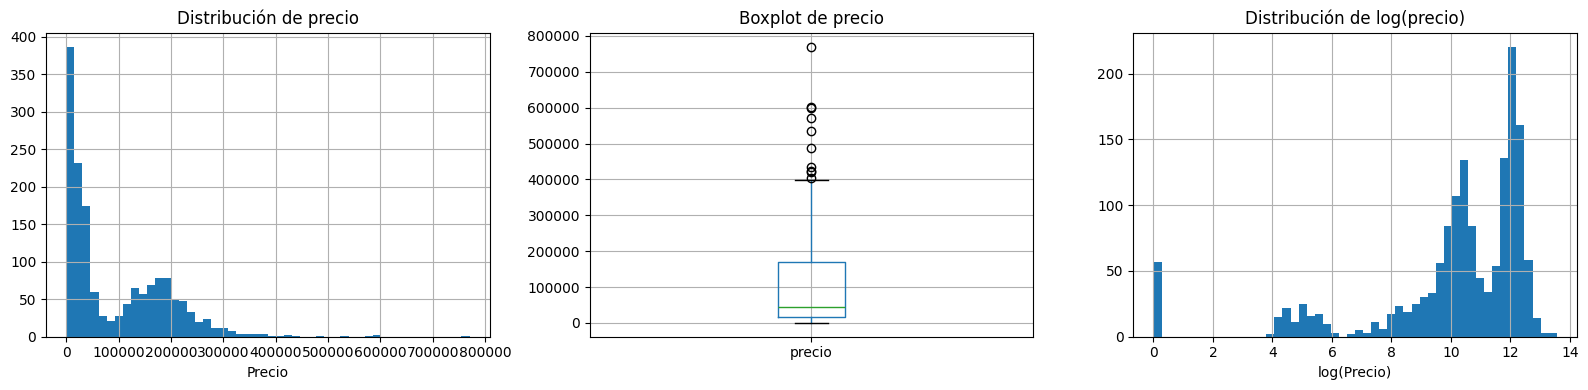

count      1545.000000
mean      93343.692526
std       96555.245985
min           0.000000
25%       15425.306495
50%       43042.341770
75%      169055.639631
max      769962.673560
Name: precio, dtype: float64

Skewness: 1.254


In [45]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución del precio
df['precio'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribución de precio')
axes[0].set_xlabel('Precio')

# Boxplot para ver outliers
df.boxplot(column='precio', ax=axes[1])
axes[1].set_title('Boxplot de precio')

# Distribución del log del precio
np.log1p(df['precio']).hist(bins=50, ax=axes[2])
axes[2].set_title('Distribución de log(precio)')
axes[2].set_xlabel('log(Precio)')

plt.tight_layout()
plt.show()

print(df['precio'].describe())
print(f"\nSkewness: {df['precio'].skew():.3f}")

In [58]:
# Investigá esto:
print(df[df['precio'] < 100][['precio', 'unidades', 'tipo', 'Área']].head(20))

        precio unidades   tipo        Área
6    84.244291       m2     ph  115.819630
15   94.822001       m2  depto   77.623869
21   80.746216       m2  depto   74.347339
38    0.000000       m2   casa  228.691782
43    0.000000       m2   casa  232.323738
71    0.000000     sqft  depto  826.326231
102   0.000000       m2  depto   68.203506
128  96.149413       m2  depto   70.416935
142   0.000000     sqft  depto  702.900945
156  93.759837       m2  depto   90.397938
172  76.481611       m2  depto   77.646008
180   0.000000       m2   casa  190.693267
198   0.000000       m2   casa  250.811501
199  62.677931       m2  depto   77.031365
213  86.464713       m2  depto   82.000707
236   0.000000       m2     ph  134.219848
285  63.360328       m2  depto   66.521066
306   0.000000       m2   casa  205.362880
307   0.000000       m2   casa  260.131058
313  93.285333       m2     ph  111.761338


In [61]:
print(df[(df['precio'] < 100000) & (df['precio'] > 70000)][['precio', 'unidades', 'tipo', 'Área']].head(20))

           precio unidades   tipo        Área
91   99588.776406     sqft  depto  683.320711
140  97739.536265     sqft  depto  759.309907
187  93252.453388       m2   casa  251.240126
271  73056.048325     sqft  depto  705.550414
339  77052.815041       m2   casa  201.376155
356  98088.955859     sqft  depto  664.327221
374  87909.857836       m2   casa  255.041945
401  92206.440104     sqft  depto  816.985559
430  98378.506404     sqft  depto  785.068081
440  82019.247854       m2   casa  219.148678
455  87903.055361       m2   casa  241.225868
470  90851.496089       m2   casa  245.360778
488  72811.487850     sqft  depto  822.702723
552  99526.079362     sqft  depto  708.687659
607  91420.590863     sqft  depto  840.058749
646  80076.837989       m2   casa  257.215489
653  80591.309604     sqft  depto  759.632140
678  80980.916391     sqft  depto  762.122211
705  76836.108191       m2   casa  227.126450
738  92922.351730     sqft  depto  810.547605


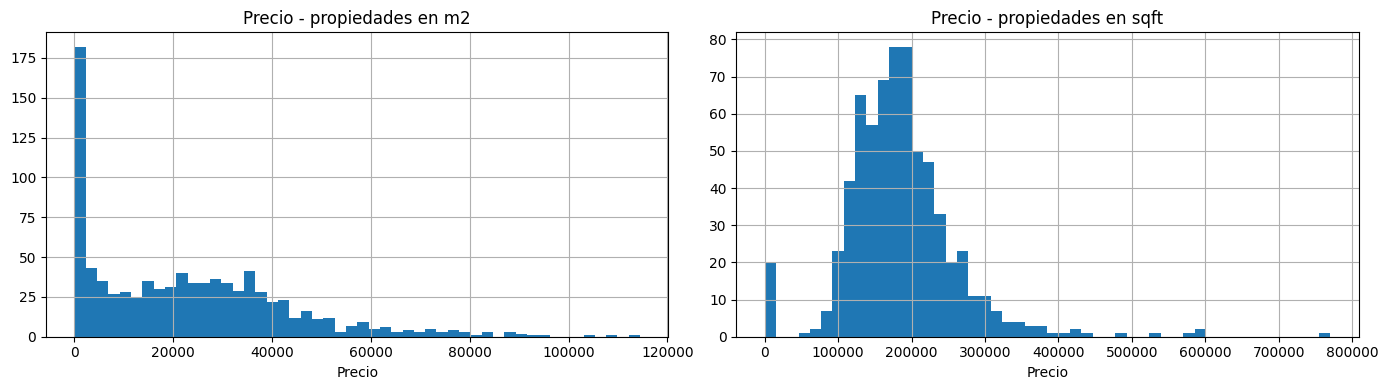

Estadísticas precio en m2:
count       876.000000
mean      23021.185463
std       20631.981961
min           0.000000
25%        4130.007417
50%       20865.868299
75%       35116.067489
max      114468.672042
Name: precio, dtype: float64

Estadísticas precio en sqft:
count       669.000000
mean     185425.181596
std       77552.550549
min           0.000000
25%      139937.555600
50%      179347.253703
75%      219477.145996
max      769962.673560
Name: precio, dtype: float64


In [62]:
# Distribucion de precio separado por unidades
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['unidades']=='m2']['precio'].hist(bins=50, ax=axes[0])
axes[0].set_title('Precio - propiedades en m2')
axes[0].set_xlabel('Precio')

df[df['unidades']=='sqft']['precio'].hist(bins=50, ax=axes[1])
axes[1].set_title('Precio - propiedades en sqft')
axes[1].set_xlabel('Precio')

plt.tight_layout()
plt.show()

print("Estadísticas precio en m2:")
print(df[df['unidades']=='m2']['precio'].describe())
print("\nEstadísticas precio en sqft:")
print(df[df['unidades']=='sqft']['precio'].describe())

In [63]:
# Investigá la composicion de ese pico
print(df[(df['unidades']=='m2') & (df['precio'] < 1000)][['precio','tipo','Área','metros_cubiertos']].head(20))
print(f"\nCuántos registros: {len(df[(df['unidades']=='m2') & (df['precio'] < 1000)])}")

         precio   tipo        Área  metros_cubiertos
6     84.244291     ph  115.819630         89.400354
15    94.822001  depto   77.623869         74.044851
16   175.665971     ph  137.816833        116.687955
20   204.631489   casa  219.806668        109.071154
21    80.746216  depto   74.347339         72.731793
38     0.000000   casa  228.691782        144.378650
43     0.000000   casa  232.323738        123.652062
60   147.258399  depto   85.483453         83.647982
66   274.461516   casa  224.485049        116.102638
79   133.177442     ph  123.232857        105.064330
98   251.874318   casa  203.856713        118.925391
102    0.000000  depto   68.203506         65.069758
109  120.632800     ph  123.447567         89.145263
128   96.149413  depto   70.416935         68.763169
131  280.966993   casa  258.995517        195.295818
139  179.184200  depto   75.542104         72.453030
147  112.753431     ph  115.183001         97.823008
156   93.759837  depto   90.397938         86.

In [66]:
# Cuántos son = 0 vs > 0 dentro de ese grupo
mask_m2_bajo = (df['unidades']=='m2') & (df['precio'] < 1000)
print(df[mask_m2_bajo]['precio'].value_counts().head(10))
print(f"\nIguales a 0: {(df[mask_m2_bajo]['precio'] == 0).sum()}")
print(f"Mayores a 0: {(df[mask_m2_bajo]['precio'] > 0).sum()}")

precio
0.000000      37
84.244291      1
158.024783     1
248.572900     1
138.944830     1
106.354645     1
107.787911     1
98.878576      1
90.161279      1
367.381505     1
Name: count, dtype: int64

Iguales a 0: 37
Mayores a 0: 125


In [67]:
print(f"Zeros en sqft: {((df['unidades']=='sqft') & (df['precio']==0)).sum()}")
print(f"Precios bajos en sqft (< 1000): {((df['unidades']=='sqft') & (df['precio']< 1000) & (df['precio']>0)).sum()}")

Zeros en sqft: 20
Precios bajos en sqft (< 1000): 0


count    1451.000000
mean       22.921058
std        21.160659
min         1.000000
25%         7.004693
50%        13.101679
75%        37.929431
max        96.440005
Name: edad, dtype: float64

Skewness de edad: 1.066


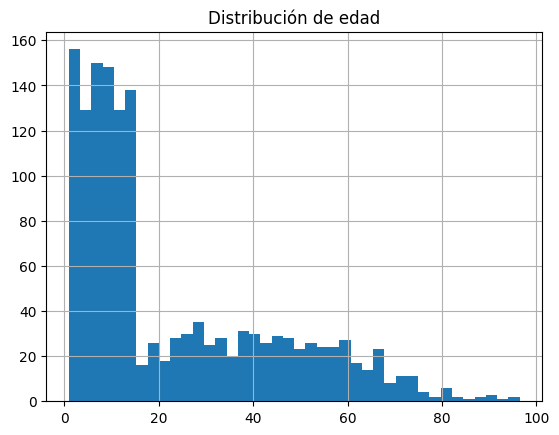

In [68]:
# Antes de decidir, mirá esto:
print(df['edad'].describe())
print(f"\nSkewness de edad: {df['edad'].skew():.3f}")
df['edad'].hist(bins=40)
plt.title('Distribución de edad')
plt.show()

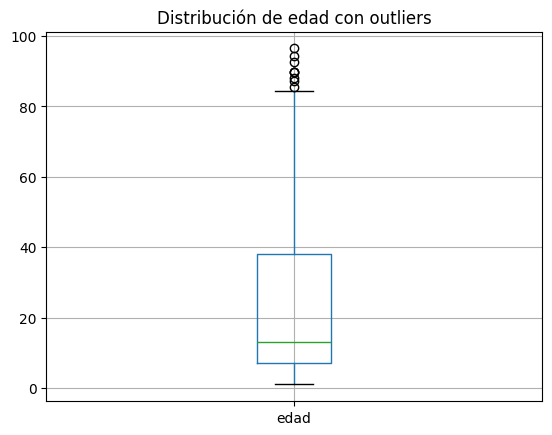

Propiedades con edad > 60 años: 108
Propiedades con edad > 80 años: 15


In [69]:
# Una última cosa antes de cerrar el diagnóstico:
df.boxplot(column='edad')
plt.title('Distribución de edad con outliers')
plt.show()

print(f"Propiedades con edad > 60 años: {(df['edad'] > 60).sum()}")
print(f"Propiedades con edad > 80 años: {(df['edad'] > 80).sum()}")

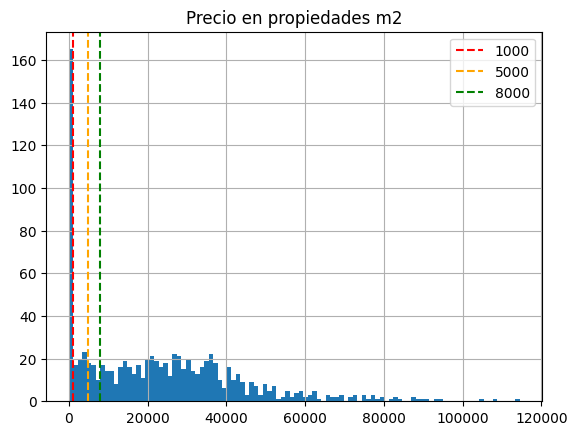

Precio entre 0 y 1000: 125 registros
Precio entre 0 y 2000: 143 registros
Precio entre 0 y 5000: 197 registros
Precio entre 0 y 8000: 233 registros
Precio entre 0 y 10000: 262 registros


In [70]:
mask_m2 = df['unidades'] == 'm2'
df[mask_m2]['precio'].hist(bins=100)
plt.title('Precio en propiedades m2')
plt.axvline(x=1000, color='red', linestyle='--', label='1000')
plt.axvline(x=5000, color='orange', linestyle='--', label='5000')
plt.axvline(x=8000, color='green', linestyle='--', label='8000')
plt.legend()
plt.show()

# Cuántos registros caen entre distintos umbrales
for umbral in [1000, 2000, 5000, 8000, 10000]:
    n = ((df['unidades']=='m2') & 
         (df['precio'] > 0) & 
         (df['precio'] < umbral)).sum()
    print(f"Precio entre 0 y {umbral}: {n} registros")

In [71]:
# Miremos el rango completo de los "ambiguos"
mask_ambiguos = ((df['unidades']=='m2') & 
                 (df['precio'] > 1000) & 
                 (df['precio'] < 10000))

print(df[mask_ambiguos][['precio','tipo','Área','metros_cubiertos','ambientes']].describe())
print(f"\nTotal: {mask_ambiguos.sum()} registros")

            precio        Área  metros_cubiertos   ambientes
count   137.000000  137.000000        137.000000  137.000000
mean   5183.863453  129.840923         96.056959    6.759124
std    2541.935294   69.986863         33.753149    2.513275
min    1053.042860   56.768296         54.068300    1.000000
25%    3160.794986   72.365446         70.490720    5.000000
50%    4861.791167   79.653715         77.996635    7.000000
75%    7366.432257  204.230709        119.139785   10.000000
max    9927.544846  253.865431        193.691507   10.000000

Total: 137 registros


In [3]:
df.describe()

,precio,Área,metros_cubiertos,ambientes,pisos,lat,lon,edad
count,1545.000000,1600.000000,1600.000000,1600.000000,748.000000,1600.000000,1600.000000,1451.000000
mean,93343.692526,441.793691,389.079682,6.915000,2.617647,-2.060019,-65.065245,22.921058
std,96555.245985,312.059318,316.426294,2.491316,0.671316,37.430008,7.802823,21.160659
min,0.000000,54.214835,52.612659,1.000000,1.000000,-34.861494,-74.058871,1.000000
25%,15425.306495,213.297952,114.295562,5.000000,2.000000,-34.782040,-73.987461,7.004693
50%,43042.341770,251.370981,166.433788,7.000000,3.000000,-34.704058,-58.288150,13.101679
75%,169055.639631,734.053341,712.503363,10.000000,3.000000,40.730409,-58.244678,37.929431
max,769962.673560,2475.718589,1553.965444,10.000000,3.000000,40.851404,-58.159866,96.440005


In [9]:
df.corr(numeric_only=True)

,precio,Área,metros_cubiertos,ambientes,pisos,pileta,lat,lon,edad
precio,1.000000,0.869430,0.854905,-0.321341,-0.233007,-0.296476,0.833830,-0.833556,-0.373720
Área,0.869430,1.000000,0.980285,-0.307494,-0.228671,-0.320985,0.922464,-0.922534,-0.398188
metros_cubiertos,0.854905,0.980285,1.000000,-0.363132,-0.267257,-0.374105,0.969638,-0.969684,-0.495114
ambientes,-0.321341,-0.307494,-0.363132,1.000000,0.655090,0.286818,-0.450836,0.450831,0.457735
pisos,-0.233007,-0.228671,-0.267257,0.655090,1.000000,0.141420,-0.333752,0.333100,0.106830
pileta,-0.296476,-0.320985,-0.374105,0.286818,0.141420,1.000000,-0.403492,0.403619,0.349147
lat,0.833830,0.922464,0.969638,-0.450836,-0.333752,-0.403492,1.000000,-0.999989,-0.580924
lon,-0.833556,-0.922534,-0.969684,0.450831,0.333100,0.403619,-0.999989,1.000000,0.580952
edad,-0.373720,-0.398188,-0.495114,0.457735,0.106830,0.349147,-0.580924,0.580952,1.000000


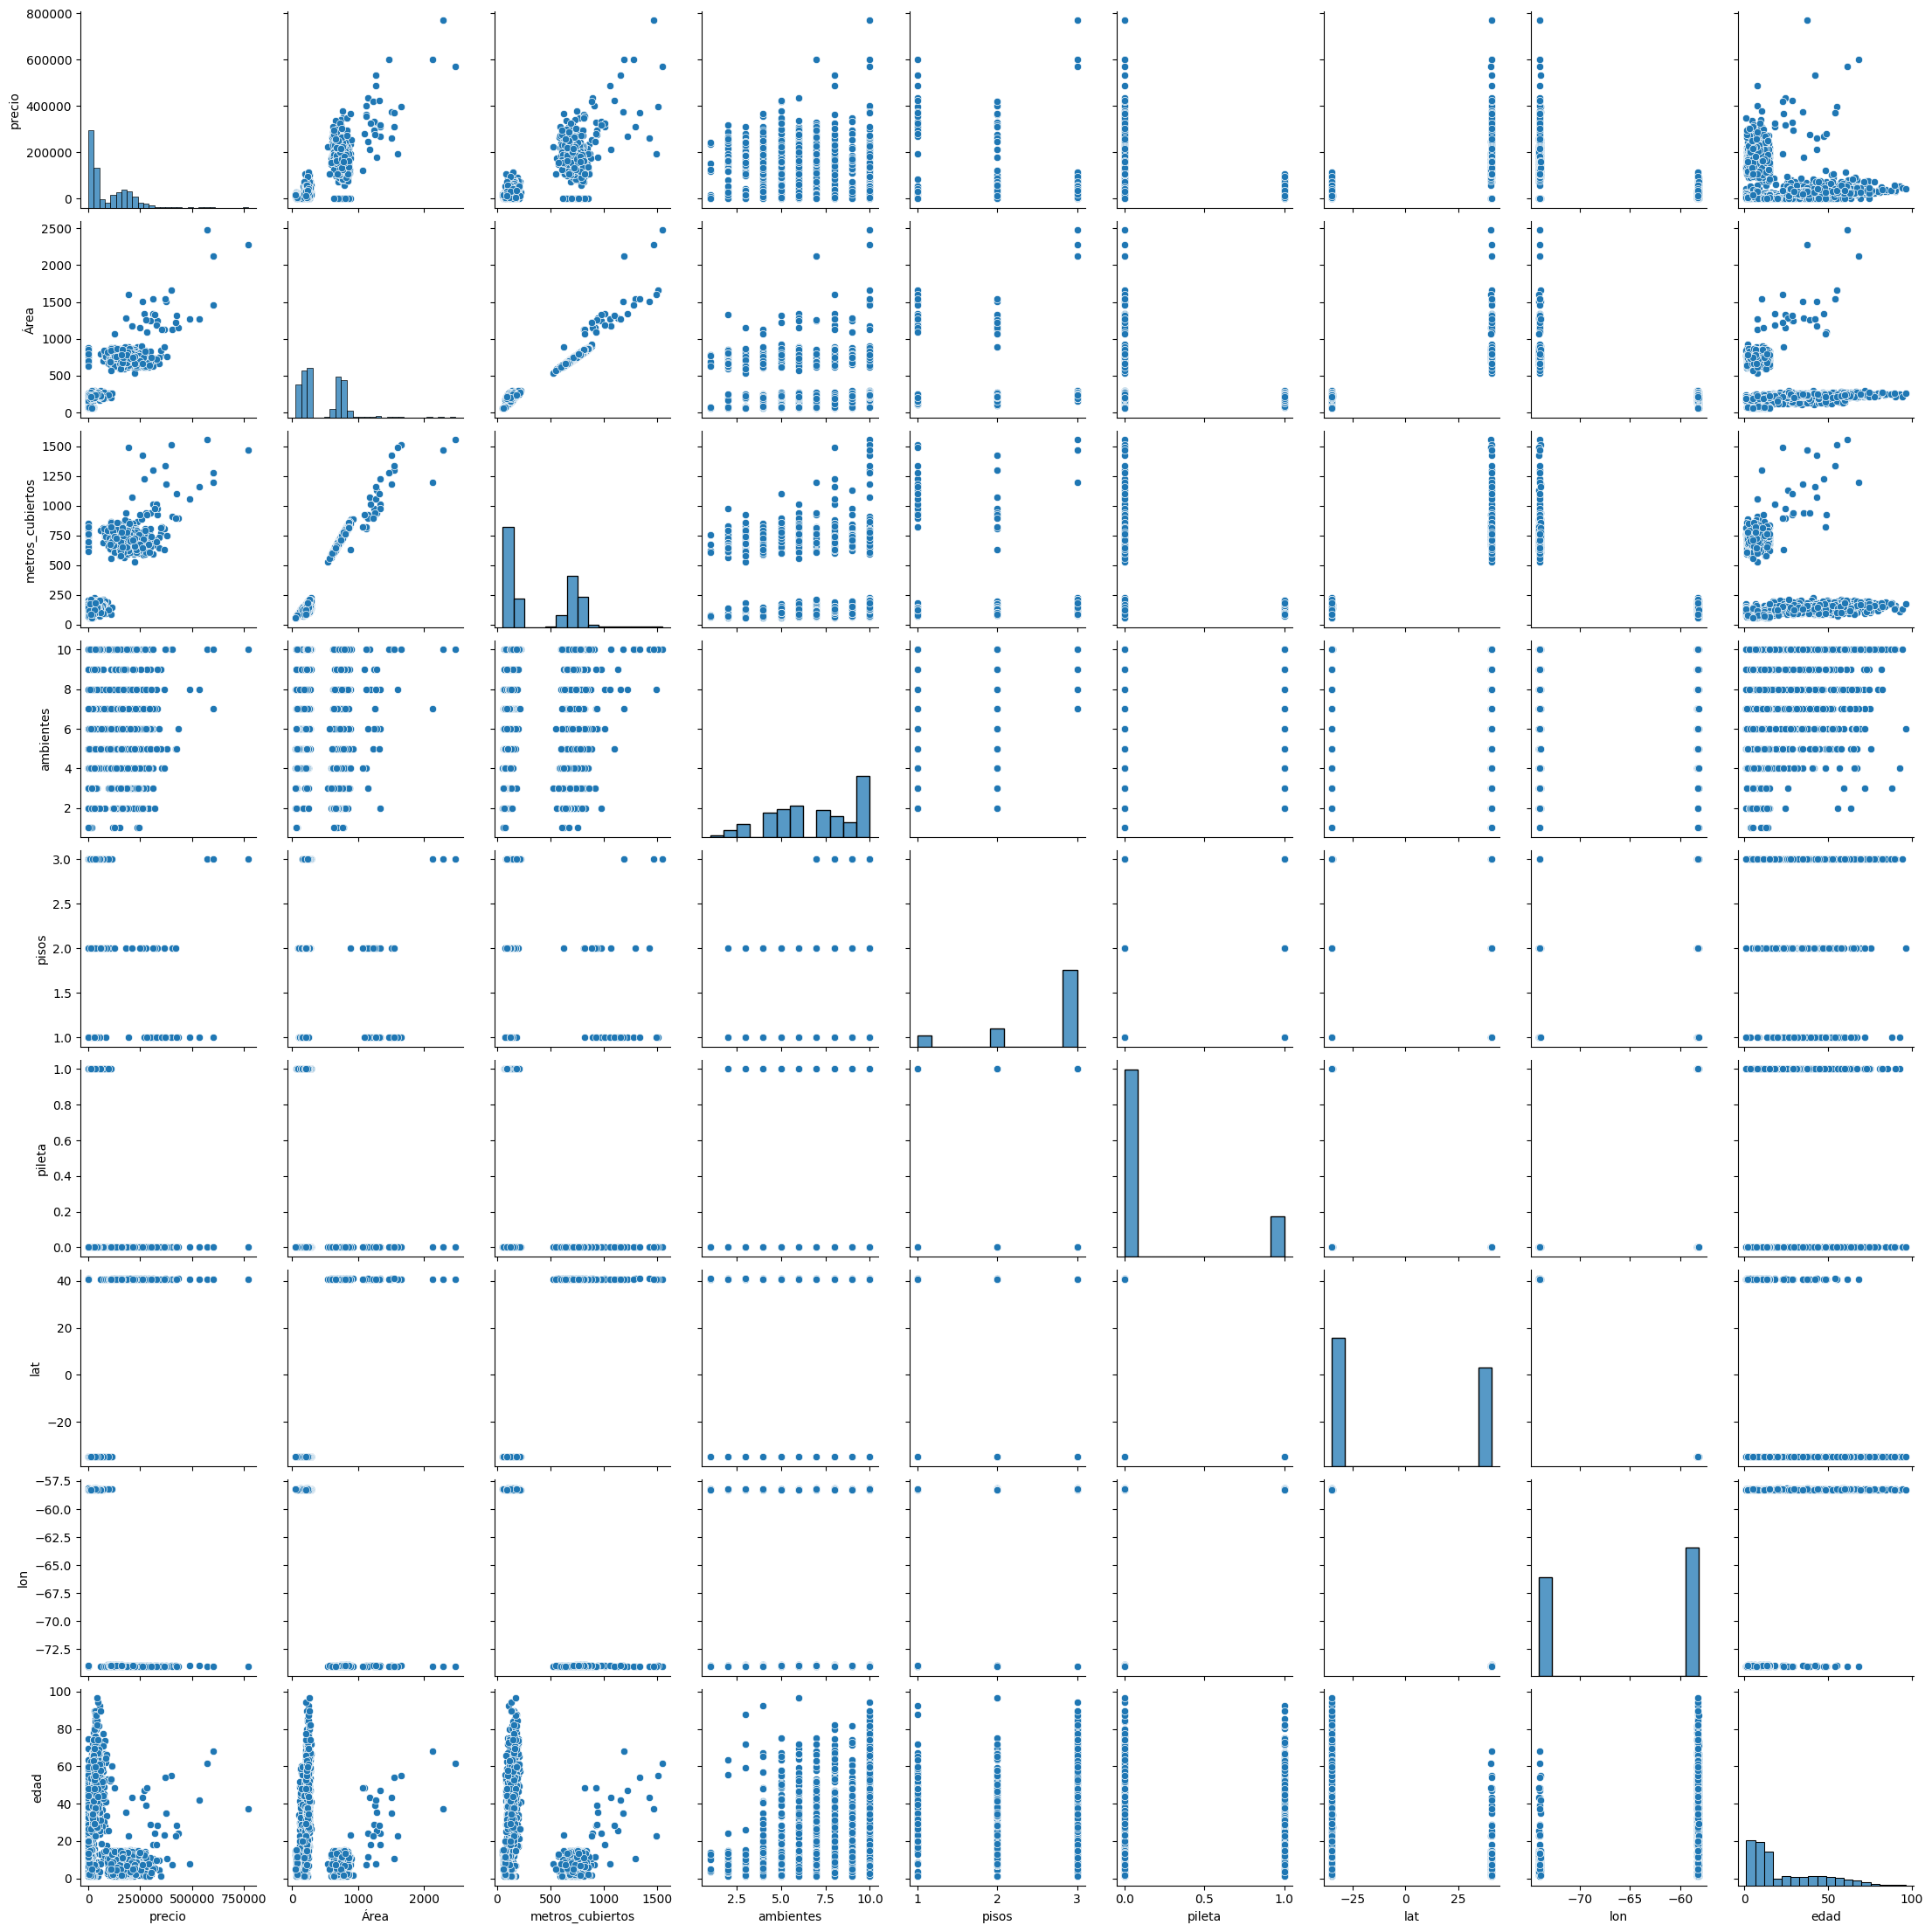

In [8]:
sns.pairplot(df)